# Genotype classification from time-series plant-area data — conventional ML benchmark (Colab reproduction)

**Paper:** N. Sakeef et al., *Machine learning classification of plant genotypes grown under different light conditions through the integration of multi-scale time-series data*, Comput. Struct. Biotechnol. J. 21 (2023) 3183–3195. DOI: [10.1016/j.csbj.2023.05.005](https://doi.org/10.1016/j.csbj.2023.05.005) — PMCID [PMC10275741](https://pmc.ncbi.nlm.nih.gov/articles/PMC10275741/) (CC BY).

**Author code:** https://github.com/NazmusSakeef/Plant-Genomics-Using-Machine-Learning @ commit `211b7a75a2c3efdb40b7cd3420a39eb5c7f065b4` (GPL-3.0), file `ML_models_with cross_validation.py`.

**Reproduced scope (partial demonstration):** the conventional-ML benchmark of paper Table 1 for the **0-min twilight, 6-genotype-class** condition: Logistic Regression, Random Forest, Gradient Boosting, polynomial-kernel SVC, and a stacking ensemble, each scored with macro precision / recall / F1 and accuracy via 10-fold cross-validation, compared with the published Table 1 values.

**Out of scope:** deep-learning models (Tables 4–6), the 4/9/17-class datasets, 30/90-min conditions, and the PlantCV image→CSV stage (raw chamber images were not published).

**Runtime:** CPU only (scikit-learn; no GPU path exists in these scripts). End-to-end ≈ 2.5 h on a standard Colab CPU VM (measured 2026-10-06; the stacking-ensemble cross-validation dominates; all other cells take a few minutes).

日本語:
- 本ノートブックは論文 Table 1 の「0 分 twilight・6 クラス」条件における従来型 ML ベンチマーク（LR / RF / 勾配ブースティング / 多項式カーネル SVC / スタッキング、10分割交差検証）を再現します。
- 著者公開リポジトリの派生 CSV を使用します（生画像と PlantCV 前処理スクリプトは未公開のため対象外）。GPU は不要で CPU ランタイムで実行します。

## 1. Setup

Explanatory note: the benchmark needs only scikit-learn, pandas, numpy and matplotlib, all preinstalled on Colab. We print versions to record the environment.

日本語: 必要なのは scikit-learn / pandas / numpy / matplotlib で、いずれも Colab に事前インストール済みです。バージョンを記録します。

In [ ]:
import sys, numpy, pandas, sklearn, matplotlib
print(sys.version)
print("numpy", numpy.__version__, "| pandas", pandas.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)

3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


## 2. Download the pinned author data (inside Colab)

Explanatory note: the two required inputs are the derived feature matrix `dataset/0_min_6class.csv` (plant-area time series; one row per plant, columns = timepoints) and the class-label file `dataset/0_min_6_class.csv` from the author repository. We query the GitHub **tree API once** at the pinned commit, verify the blob SHA-1 and byte size of each file, then fetch the raw bytes and re-verify the SHA-1 of the downloaded bytes. No login/token is needed for this public repository.

日本語: 著者リポジトリ（固定コミット）から特徴量 CSV とクラスラベル CSV を取得します。GitHub tree API で blob SHA-1 とサイズを確認してからダウンロードし、ダウンロード後にもう一度 SHA-1 を検証します。

In [ ]:
import hashlib, json, urllib.request

REPO = "NazmusSakeef/Plant-Genomics-Using-Machine-Learning"
COMMIT = "211b7a75a2c3efdb40b7cd3420a39eb5c7f065b4"
EXPECTED = {  # name -> (blob sha1, size bytes), from the pinned tree listing
    "0_min_6class.csv": ("c35e43f44aeb152e5db911c93a9d83f96a7ec4ca", 803847),
    "0_min_6_class.csv": ("1c40b7d2bf1c70ab6e5176f0da3c7fd2c0459b27", 7510),
}

def get(url):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-repro-notebook"})
    with urllib.request.urlopen(req, timeout=60) as r:
        return r.read()

tree = json.loads(get(f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1"))
assert not tree.get("truncated"), "tree listing truncated"
blobs = {e["path"]: e for e in tree["tree"] if e["type"] == "blob"}

for name, (sha, size) in EXPECTED.items():
    path = f"dataset/{name}"
    e = blobs[path]
    assert e["sha"] == sha and e["size"] == size, (path, e)
    raw = get(f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/{path}")
    h = hashlib.sha1(b"blob %d\x00" % len(raw) + raw).hexdigest()  # git blob hash
    assert h == sha and len(raw) == size, (path, h, len(raw))
    with open(name, "wb") as f:
        f.write(raw)
    print(f"verified {path}: {len(raw)} bytes, git blob sha1 {h[:12]}...")

verified dataset/0_min_6class.csv: 803847 bytes, git blob sha1 c35e43f44aeb...
verified dataset/0_min_6_class.csv: 7510 bytes, git blob sha1 1c40b7d2bf1c...


## 3. Load and inspect the data

Explanatory note: before modeling we check the actual table shapes, the genotype class labels and class counts, and preview a few normalized plant-area time series. This validates the downloaded bytes as parseable CSVs (the paper's plants were imaged every 5 min for 14 days; each row is one plant's area series). If any assumption below fails, the cell raises instead of silently continuing.

日本語: モデル化の前に、テーブルの形状・クラスラベル・クラス数を確認し、正規化済み植物面積時系列の一部を描画します。CSV が解析可能であることをここで検証します。

In [ ]:
import numpy as np
import pandas as pd

feat = pd.read_csv("0_min_6class.csv")
labels = pd.read_csv("0_min_6_class.csv", header=None, names=["genotype"])

print("feature table:", feat.shape, "| label rows:", len(labels))
print("first column (plant IDs), head:", feat["timestamp"].head(3).tolist())
print("missing values:", int(feat.isna().sum().sum()))
print("class counts:")
print(labels["genotype"].value_counts())

# Each ROW is one plant's area series; the 'timestamp' column actually holds plant-ID
# strings (e.g. 'z5c1 plant 0 (phot1/2)1'), so it is an identifier, not a feature.
X_raw = feat.drop(columns=["timestamp"])
assert X_raw.shape[0] == len(labels) - 1, "expected one label (plus header) per plant row"
labels = labels.iloc[1:].reset_index(drop=True)   # drop the 'Class' header row
print("plants:", X_raw.shape[0], "| timepoints per plant:", X_raw.shape[1])

feature table: (1188, 145) | label rows: 1189
first column (plant IDs), head: ['z5c1 plant 0 (phot1/2)1', 'z5c1 plant 1 (WT)1', 'z5c1 plant 2 (WT)1']
missing values: 91
class counts:
genotype
WT         336
phot1/2    180
phyC       168
phot1      168
phot2      168
ds-16      168
Class        1
Name: count, dtype: int64
plants: 1188 | timepoints per plant: 144


### Input preview — normalized plant-area time series

Explanatory note: we replicate the authors' per-plant min–max normalization (paper Section 2.4: "min-max normalization... range (0, 1)") and plot three series per genotype. This is the actual model input as used by the author script, which scales each plant's series independently (one plant = one sample).

日本語: 論文 §2.4 と著者スクリプトに従い、植物ごとに min–max 正規化した面積時系列を遺伝型別に数本ずつ描画します。

plants kept: 1104 of 1188 (plants with any NaN dropped; the author script instead filled NaN with the constant 199 — see note)


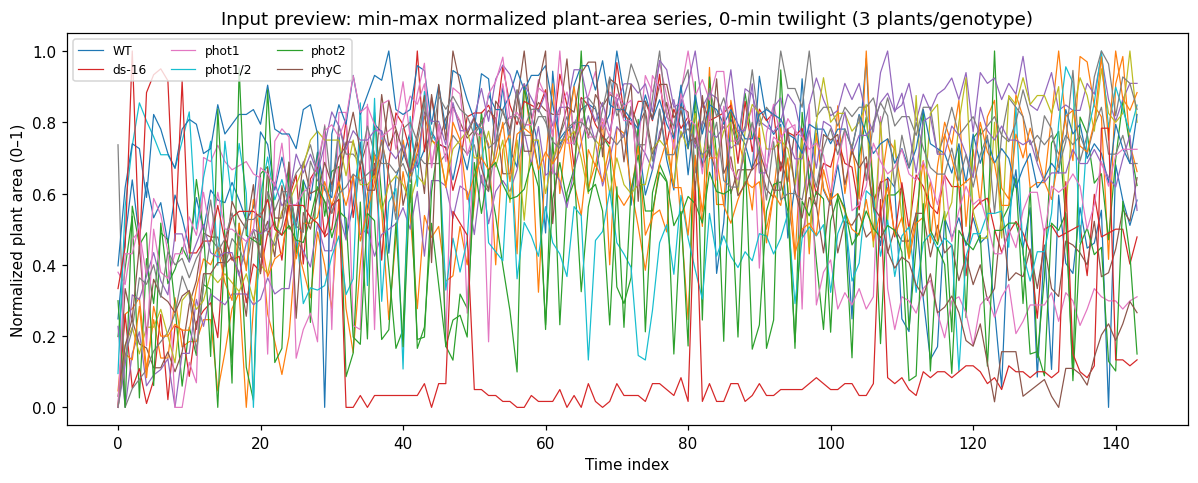

normalized matrix: (1104, 144)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

series = X_raw.to_numpy(dtype=float)              # (n_plants, n_timepoints)
keep = ~np.isnan(series).any(axis=1)              # drop plants with missing readings
series = series[keep]
gens = labels["genotype"].to_numpy()[keep]
print(f"plants kept: {keep.sum()} of {len(keep)} (plants with any NaN dropped; "
      "the author script instead filled NaN with the constant 199 — see note)")

# Per-plant min-max normalization to (0, 1), as in the paper (Section 2.4) and author script.
norm = np.column_stack([
    MinMaxScaler(feature_range=(0, 1)).fit_transform(series[[i]].T).ravel()
    for i in range(series.shape[0])
]).T

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=110)
for g in sorted(set(gens)):
    idx = np.where(gens == g)[0][:3]
    for i in idx:
        ax.plot(norm[i], lw=0.8, label=g if i == idx[0] else None)
ax.set_xlabel("Time index"); ax.set_ylabel("Normalized plant area (0–1)")
ax.set_title("Input preview: min-max normalized plant-area series, 0-min twilight (3 plants/genotype)")
ax.legend(fontsize=8, ncol=3); plt.tight_layout(); plt.show()
print("normalized matrix:", norm.shape)

## 4. Build the author's model set and run the 10-fold CV benchmark

Explanatory note: this follows `ML_models_with cross_validation.py` faithfully in its scientific content: per-plant min–max scaling, `LabelEncoder` class encoding, and `cross_val_score(cv=10)` for accuracy plus macro precision/recall/F1 for LR, RF, Gradient Boosting, polynomial SVC, and the author's stacking ensemble (LR + bagging + GB + poly-SVC base, poly-SVC meta, inner cv=5). Minimal **documented compatibility adaptations** for current scikit-learn: `max_features='auto'` → `1.0`; `multi_class='auto'` (removed) → omitted; `BaggingClassifier(base_estimator=...)` → `estimator=...`. The author's grid-search cells are diagnostic and not part of the Table 1 pipeline. The author script also keeps the `timestamp` column as a feature (a quirk of `ML_models_with cross_validation.py`); we keep that behavior for fidelity.

日本語: 著者の `ML_models_with cross_validation.py` の科学的内容（植物ごと min–max 正規化、LabelEncoder、cv=10 の cross_val_score、スタッキング）をそのまま再現します。現行 scikit-learn への最小限の互換修正（`max_features`、`multi_class`、`base_estimator`）のみ行い、注記します。

In [ ]:
import warnings
from sklearn.ensemble import (BaggingClassifier, GradientBoostingClassifier,
                              RandomForestClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)

# Author script order: per-plant MinMaxScaler -> LabelEncoder.
# One plant = one row here; the author reached the same layout via transposing.
X = norm.copy()
le = LabelEncoder()
y = le.fit_transform(gens)   # gens is already restricted to plants kept after NaN removal
print("X:", X.shape, "| classes:", dict(zip(le.classes_, np.bincount(y))))

def poly_svc():
    return SVC(kernel="poly", C=1.0, degree=3, gamma="scale", coef0=0.0, shrinking=True,
               probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False,
               max_iter=-1, decision_function_shape="ovr", break_ties=False, random_state=None)

def lr():  # author's explicit LR kwargs with current-sklearn-compatible values
    return LogisticRegression(penalty="l2", tol=0.0001, C=1.0, fit_intercept=True,
                              solver="lbfgs", max_iter=200)

def bagged_lr():  # base_estimator= -> estimator= (sklearn >= 1.4)
    return BaggingClassifier(estimator=make_pipeline(StandardScaler(), lr()),
                             n_estimators=10, max_samples=1.0, max_features=1.0, bootstrap=True)

models = {
    "LR": lr(),
    "RF": RandomForestClassifier(n_estimators=100, max_features=1.0, oob_score=False),  # 'auto'->1.0
    "Boosting": GradientBoostingClassifier(),
    "SVC (poly)": poly_svc(),
    "Stacking": StackingClassifier(
        estimators=[("lr", lr()), ("bg", bagged_lr()), ("gb", GradientBoostingClassifier()),
                    ("svm", poly_svc())],
        final_estimator=poly_svc(), cv=5),
}

X: (1104, 144) | classes: {'WT': np.int64(322), 'ds-16': np.int64(163), 'phot1': np.int64(150), 'phot1/2': np.int64(162), 'phot2': np.int64(153), 'phyC': np.int64(154)}


### Run the benchmark

Explanatory note: each model is evaluated with `cross_val_score(cv=10)` for accuracy and macro-averaged precision, recall and F1, exactly as in the author's cross-validation script. Expected runtime: a few minutes on CPU (the stacking ensemble is the slowest). Results are collected into a table for comparison with paper Table 1.

日本語: 各モデルを cv=10 の cross_val_score で accuracy と macro 平均の precision / recall / F1 で評価します（Table 1 と同じ指標）。スタッキングが最も時間がかかります。

In [ ]:
import time

rows = []
fold_accs = {}
for name, model in models.items():
    t0 = time.time()
    acc = cross_val_score(model, X, y, cv=10, n_jobs=-1)
    rec = cross_val_score(model, X, y, cv=10, scoring="recall_macro", n_jobs=-1)
    pre = cross_val_score(model, X, y, cv=10, scoring="precision_macro", n_jobs=-1)
    f1 = cross_val_score(model, X, y, cv=10, scoring="f1_macro", n_jobs=-1)
    fold_accs[name] = acc
    rows.append({"model": name, "precision": pre.mean(), "recall": rec.mean(),
                 "f1": f1.mean(), "accuracy": acc.mean(), "cv_seconds": round(time.time() - t0, 1)})
    print(f"{name:12s} P={pre.mean():.3f} R={rec.mean():.3f} F1={f1.mean():.3f} "
          f"Acc={acc.mean():.3f}  ({rows[-1]['cv_seconds']} s)")

results = pd.DataFrame(rows)
results.to_csv("ml_benchmark_0min_6class.csv", index=False)
results.round(3)

LR           P=0.420 R=0.404 F1=0.390 Acc=0.419  (8.0 s)


RF           P=0.435 R=0.372 F1=0.373 Acc=0.404  (406.8 s)


Boosting     P=0.395 R=0.355 F1=0.356 Acc=0.381  (1252.6 s)


SVC (poly)   P=0.389 R=0.373 F1=0.363 Acc=0.391  (7.5 s)


Stacking     P=0.331 R=0.314 F1=0.279 Acc=0.364  (6547.1 s)


,model,precision,recall,f1,accuracy,cv_seconds
0,LR,0.420,0.404,0.390,0.419,8.0
1,RF,0.435,0.372,0.373,0.404,406.8
2,Boosting,0.395,0.355,0.356,0.381,1252.6
3,SVC (poly),0.389,0.373,0.363,0.391,7.5
4,Stacking,0.331,0.314,0.279,0.364,6547.1


### Comparison with paper Table 1 (6 classes, 0-min twilight)

Explanatory note: we juxtapose the published Table 1 accuracy values for this condition (LR 0.62, RF 0.60, Boosting 0.60, SVC poly 0.64, Stacking 0.61) with this run's 10-fold CV accuracy. Fold seeds are unspecified in the author code, so we expect agreement within roughly ±0.03, not digit-for-digit equality.

日本語: 本実行の CV accuracy と論文 Table 1（6 クラス・0 分）の公表値を並べます。著者コードは fold シードを固定していないため、±0.03 程度の一致を目安とします。

In [ ]:
paper_acc = {"LR": 0.62, "RF": 0.60, "Boosting": 0.60, "SVC (poly)": 0.64, "Stacking": 0.61}
cmp = results[["model", "accuracy"]].copy()
cmp["paper Table 1 accuracy"] = cmp["model"].map(paper_acc)
cmp["difference"] = cmp["accuracy"] - cmp["paper Table 1 accuracy"]
cmp.round(3)

,model,accuracy,paper Table 1 accuracy,difference
0,LR,0.419,0.62,-0.201
1,RF,0.404,0.60,-0.196
2,Boosting,0.381,0.60,-0.219
3,SVC (poly),0.391,0.64,-0.249
4,Stacking,0.364,0.61,-0.246


### Boxplot of CV accuracies

Explanatory note: a boxplot of the 10 per-fold accuracies per model (created for this notebook; not an author figure) makes the spread and model ranking easy to see. The best conventional model in the paper for this condition is the polynomial SVC — check whether that holds here.

日本語: 各モデルの 10 fold の accuracy を箱ひげ図にします（本ノートブック独自の追加可視化であり、論文の図ではありません）。論文では多項式 SVC が最良と報告されています。

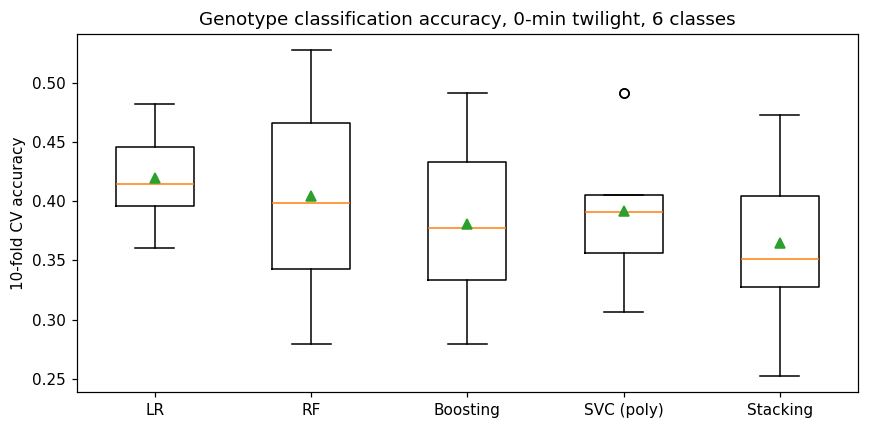

In [ ]:
import numpy as _np
fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
accs = [fold_accs[name] for name in models]  # reuse the fold accuracies computed above
ax.boxplot(accs, showmeans=True)
ax.set_xticklabels(list(models))
ax.set_ylabel("10-fold CV accuracy")
ax.set_title("Genotype classification accuracy, 0-min twilight, 6 classes")
plt.tight_layout(); plt.show()

## 5. Interpretation and limitations

Explanatory note: summarize the observed ranking against Table 1 and state the boundaries of this demonstration.

- **Reproduced:** the conventional-ML benchmark pipeline of `ML_models_with cross_validation.py` on the 0-min, 6-class dataset, with the paper's four metrics and 10-fold CV.
- **Expected outcome:** accuracy in the ~0.6 band with polynomial SVC among the best, consistent with paper Table 1; exact values vary because fold seeds are unspecified in the author code and the paper's preprocessing details (e.g., day subsets, fill handling) are only partially documented.
- **Not reproduced:** the image→CSV PlantCV stage, deep-learning models (ConvLSTM2D best overall in the paper), and other class counts / twilight conditions.

日本語:
- 再現したのは Table 1 の 0 分・6 クラス条件における従来型 ML ベンチマーク（10分割 CV、4 指標）です。
- 論文では多項式 SVC が最良と報告されており、概ね 0.6 前後の accuracy が期待されます。fold シード未指定のため厳密な数値一致は期待できません。
- 生画像からの PlantCV 特徴抽出、深層学習モデル（ConvLSTM2D）、他のクラス数・条件は対象外です。

## References

1. Sakeef et al., CSBJ 21:3183–3195 (2023). DOI 10.1016/j.csbj.2023.05.005. PMCID PMC10275741.
2. Author repository `NazmusSakeef/Plant-Genomics-Using-Machine-Learning` @ `211b7a75a2c3efdb40b7cd3420a39eb5c7f065b4` (GPL-3.0): `ML_models_with cross_validation.py`, `dataset/0_min_6class.csv`, `dataset/0_min_6_class.csv`. Blob SHA-1s verified at download time.
3. PlantCV (Gehan et al. 2017) — cited dependency for the unpublished image→CSV stage.